In [8]:
# === Backtesting Engine: 2021 - 2023 (Monthly Rebalance, 3-Month Rolling Window) ===

import yfinance as yf
import pennylane as qml
from pennylane import numpy as pnp
import numpy as np
import pandas as pd
import scipy.linalg as la
import matplotlib.pyplot as plt
from itertools import combinations
import warnings

warnings.filterwarnings('ignore')

print("Starting Setup for Backtesting (2021-2023)...")

Starting Setup for Backtesting (2021-2023)...


In [ ]:
# 1. Konfigurasi
tickers = ['BBRI.JK', 'BMRI.JK', 'TLKM.JK', 'ASII.JK1']
K = 2
penalty_A = 5.0
depth = 1  # Kedalaman Ansatz EfficientSU2
maxiter = 100 # Iterasi SPSA

# Parameter Kalender
initial_capital = 100_000_000.0
# Di bursa, 1 bulan ~ 21 hari perdagangan, 3 bulan ~ 63 hari perdagangan
lookback_days = 63 
rebalance_days = 21 

# 2. Download Data
data = yf.download(tickers, start="2020-09-01", end="2024-01-01", progress=False)['Close']
data = data.dropna()
data_clean = data.sort_index()

print(f"Data Berhasil Diunduh. Total hari observasi: {len(data_clean)}")

Data Berhasil Diunduh. Total hari observasi: 813


In [10]:
# Helper Function: Extract QMI, Bias, Payoffs, and Build Hamiltonian (mirip cell sebelumnya)
def compute_endogenous_lambda(log_returns, tickers):
    mu_annual = log_returns[tickers].mean() * 252
    sigma_annual = log_returns[tickers].std() * np.sqrt(252)
    mu_avg = abs(mu_annual).mean()
    sigma_avg = sigma_annual.mean()
    if np.isnan(mu_avg) or np.isnan(sigma_avg) or (mu_avg + sigma_avg) == 0:
        return 0.5 
    # Sigmoid / Logistic function based on Sharpe Ratio
    Z = mu_avg / sigma_avg
    return 1.0 / (1.0 + np.exp(Z))

# === GAME THEORY CLASSIFICATION & BIAS PIPELINE ===
def classify_game(payoff_A, payoff_B):
    """
    Klasifikasi tipe game 2x2 dari payoff matrix menggunakan
    payoff ranking distance + softmax → probabilitas.
    
    Konvensi payoff matrix:
      payoff_A[i, j] = payoff pemain A saat A=strategi i, B=strategi j
      Strategi 0 = 'Cooperate' / 'Not Invest', Strategi 1 = 'Defect' / 'Invest'
    
    Konvensi game theory standar (dari sudut pandang pemain A):
      R = payoff_A[0,0]  (kedua cooperate)
      S = payoff_A[0,1]  (A cooperate, B defect)
      T = payoff_A[1,0]  (A defect, B cooperate)
      P = payoff_A[1,1]  (kedua defect)
    """
    # Extract T, R, P, S dari payoff matrix pemain A
    R_a = payoff_A[0, 0]
    S_a = payoff_A[0, 1]
    T_a = payoff_A[1, 0]
    P_a = payoff_A[1, 1]
    
    vals = np.array([T_a, R_a, P_a, S_a])  # posisi: T, R, P, S
    
    # Ranking ideal per game type (ranking 4=highest, 1=lowest)
    # Format: [rank_T, rank_R, rank_P, rank_S]
    ideal_rankings = {
        'PD':  np.array([4, 3, 2, 1]),   # T > R > P > S  (Prisoner's Dilemma)
        'SH':  np.array([3, 4, 1, 2]),   # R > T > S > P  (Stag Hunt)
        'BoS': np.array([4, 3, 1, 2]),   # T > R > S > P  (Battle of Sexes)
        'CH':  np.array([4, 2, 3, 1]),   # T > P > R > S  (Chicken / Hawk-Dove)
    }
    
    # Hitung ranking aktual dari payoff
    sorted_indices = np.argsort(vals)
    actual_ranking = np.zeros(4)
    for rank, idx in enumerate(sorted_indices):
        actual_ranking[idx] = rank + 1  # 1-indexed
    
    # Hitung distance (Kendall-tau-like) ke setiap ideal ranking
    distances = {}
    for game, ideal in ideal_rankings.items():
        distances[game] = np.sum((actual_ranking - ideal) ** 2)
    
    # Softmax dengan temperature untuk menghasilkan probabilitas
    temperature = 2.0  # Semakin kecil → semakin "sharp" classification
    game_names = list(distances.keys())
    dist_vals = np.array([distances[g] for g in game_names])
    
    # Negative distance karena kita ingin distance kecil → probabilitas tinggi
    logits = -dist_vals / temperature
    logits -= np.max(logits)  # numerical stability
    exp_logits = np.exp(logits)
    probs = exp_logits / exp_logits.sum()
    
    game_probs = {g: p for g, p in zip(game_names, probs)}
    return game_probs

In [11]:
def compute_game_bias(payoff_A, payoff_B, game_probs, role='A'):
    """
    Hitung bias h_i untuk satu pasangan aset berdasarkan weighted game classification.
    
    Formula bias per game type:
      PD:  R - P   (reward vs punishment gap — insentif kooperasi)
      SH:  R - S   (reward vs sucker — risiko koordinasi gagal)
      BoS: |T - S|  (magnitude asymmetry)
      CH:  T - R   (temptation vs reward — agresivitas)
    
    Fallback 'generic' menggunakan marginal payoff (formula asal).
    """
    payoff = payoff_A if role == 'A' else payoff_B
    
    # Extract T, R, P, S
    if role == 'A':
        R = payoff[0, 0]; S = payoff[0, 1]; T = payoff[1, 0]; P = payoff[1, 1]
    else:
        # Untuk pemain B, strategi di-transpose
        R = payoff[0, 0]; S = payoff[1, 0]; T = payoff[0, 1]; P = payoff[1, 1]
    
    # Per-game bias formulas
    bias_pd  = R - P                            # Prisoner's Dilemma
    bias_sh  = R - S                             # Stag Hunt
    bias_bos = abs(T - S)                        # Battle of Sexes
    bias_ch  = T - R                             # Chicken
    
    # Marginal payoff (fallback) — formula original
    if role == 'A':
        bias_generic = (payoff_A[1, 0] + payoff_A[1, 1]) - (payoff_A[0, 0] + payoff_A[0, 1])
    else:
        bias_generic = (payoff_B[0, 1] + payoff_B[1, 1]) - (payoff_B[0, 0] + payoff_B[1, 0])
    
    # Weighted average
    bias = (
        game_probs.get('PD', 0)  * bias_pd +
        game_probs.get('SH', 0)  * bias_sh +
        game_probs.get('BoS', 0) * bias_bos +
        game_probs.get('CH', 0)  * bias_ch
    )
    
    # Tambahkan residual generic jika total prob < 1 (seharusnya tidak terjadi)
    total_classified = sum(game_probs.values())
    if total_classified < 0.999:
        bias += (1.0 - total_classified) * bias_generic
    
    return bias

In [12]:
def build_hamiltonian(h, J, n_assets, K=2, penalty_A=5.0):
    coeffs = []
    obs = []
    
    # H_cost
    for i in range(n_assets):
        if abs(h[i]) > 1e-10:
            coeffs.append(float(h[i]))
            obs.append(qml.PauliZ(i))
            
    for i in range(n_assets):
        for j in range(i + 1, n_assets):
            if abs(J[i, j]) > 1e-10:
                coeffs.append(float(J[i, j]))
                obs.append(qml.PauliZ(i) @ qml.PauliZ(j))
                
    # H_constraint (Penalty to ensure exactly K assets are chosen)
    coeffs.append(float(penalty_A))
    obs.append(qml.Identity(0)) 
    
    for pair in combinations(range(n_assets), 2):
        coeffs.append(float(penalty_A / 2))
        obs.append(qml.PauliZ(pair[0]) @ qml.PauliZ(pair[1]))
        
    return qml.Hamiltonian(coeffs, obs)

def run_vqe_spsa_pennylane(H, n_qubits, K=2, depth=1, maxiter=100, seed=42):
    # Gunakan device statik tanpa tembakan untuk optimasi kecepatan
    dev = qml.device("default.qubit", wires=n_qubits)
    
    @qml.qnode(dev)
    def cost_circuit(params):
        weights = params.reshape((depth + 1, n_qubits, 2))
        for layer in range(depth + 1):
            for q in range(n_qubits):
                qml.RY(weights[layer, q, 0], wires=q)
                qml.RZ(weights[layer, q, 1], wires=q)
            if layer < depth:
                for q in range(n_qubits - 1):
                    qml.CNOT(wires=[q, q + 1])
                qml.CNOT(wires=[n_qubits - 1, 0])
        return qml.expval(H)

    rng = np.random.default_rng(seed)
    n_params = n_qubits * 2 * (depth + 1)
    params = rng.uniform(0, 2 * np.pi, n_params)
    
    # SPSA Configuration manual update
    a = 0.1 
    c = 0.1
    A = maxiter * 0.1
    alpha = 0.602
    gamma = 0.101
    
    for k in range(maxiter):
        a_k = a / (A + k + 1) ** alpha
        c_k = c / (k + 1) ** gamma
        delta = 2 * rng.integers(0, 2, size=n_params) - 1
        
        cost_plus = float(cost_circuit(params + c_k * delta))
        cost_minus = float(cost_circuit(params - c_k * delta))
        grad = (cost_plus - cost_minus) / (2 * c_k * delta)
        params = params - a_k * grad

    # Penarikan bitstring dari hasil amplitudo
    @qml.qnode(dev)
    def prob_circuit(params):
        weights = params.reshape((depth + 1, n_qubits, 2))
        for layer in range(depth + 1):
            for q in range(n_qubits):
                qml.RY(weights[layer, q, 0], wires=q)
                qml.RZ(weights[layer, q, 1], wires=q)
            if layer < depth:
                for q in range(n_qubits - 1):
                    qml.CNOT(wires=[q, q + 1])
                qml.CNOT(wires=[n_qubits - 1, 0])
        return qml.probs(wires=range(n_qubits))

    probs = prob_circuit(params)
    
    # Pilih kombinasi K aset dengan probabilitas tertinggi 
    sorted_indices = np.argsort(probs)[::-1]
    best_bitstring = None
    for idx in sorted_indices:
        bs = format(idx, f'0{n_qubits}b')
        if bs.count('1') == K:
            best_bitstring = bs
            break
            
    if best_bitstring is None:
        best_bitstring = "0011" # Fallback if SPSA gets highly trapped
        
    # Translate bitstring ('1' artinya dipilih, karena Penalty constraint Z Z mencari eigen -1/-1)
    selected_indices = [i for i, bit in enumerate(best_bitstring) if bit == '1']
    return selected_indices

def run_strategy_step(lookback_data, tickers, K=2, penalty_A=5.0):
    log_rets = np.log(lookback_data / lookback_data.shift(1)).dropna()
    binary_sts = (log_rets <= 0).astype(int)
    
    lam = compute_endogenous_lambda(log_rets, tickers)
    
    # Payoffs & Bias h_i
    all_payoffs = {}
    pairs = list(combinations(range(len(tickers)), 2))
    
    # Re-implementasi lokal fungsi payoff & QMI untuk menghindari state luar sel
    def calc_payoff(ret_A, ret_B, st_A, st_B, lam):
        pA, pB, counts = np.zeros((2, 2)), np.zeros((2, 2)), np.zeros((2, 2))
        for t in range(len(st_A)):
            i, j = int(st_A[t]), int(st_B[t])
            counts[i, j] += 1
            u_A = (1 - lam) * (ret_A[t] * 252) - lam * abs(ret_A[t] * 252)
            u_B = (1 - lam) * (ret_B[t] * 252) - lam * abs(ret_B[t] * 252)
            pA[i, j] += u_A
            pB[i, j] += u_B
        for i in range(2):
            for j in range(2):
                if counts[i, j] > 0:
                    pA[i, j] /= counts[i, j]
                    pB[i, j] /= counts[i, j]
        return pA, pB
        
    for idx_a, idx_b in pairs:
        a, b = tickers[idx_a], tickers[idx_b]
        pA, pB = calc_payoff(log_rets[a].values, log_rets[b].values, 
                             binary_sts[a].values, binary_sts[b].values, lam)
        all_payoffs[(idx_a, idx_b)] = (pA, pB)
        
    n_assets = len(tickers)
    
    # === Game Theory Classification → Bias Selection ===
    # Klasifikasi setiap pasangan, lalu hitung bias per aset
    pair_game_probs = {}
    for (idx_a, idx_b), (pA, pB) in all_payoffs.items():
        game_probs = classify_game(pA, pB)
        pair_game_probs[(idx_a, idx_b)] = game_probs
        dominant_game = max(game_probs, key=game_probs.get)
        print(f"    Pair ({tickers[idx_a]}, {tickers[idx_b]}): "
              f"{dominant_game} ({game_probs[dominant_game]:.1%}) | "
              f"PD={game_probs['PD']:.1%} SH={game_probs['SH']:.1%} "
              f"BoS={game_probs['BoS']:.1%} CH={game_probs['CH']:.1%}")
    
    h = np.zeros(n_assets)
    for i in range(n_assets):
        bias_sum, count = 0, 0
        for (a, b), (pA, pB) in all_payoffs.items():
            gp = pair_game_probs[(a, b)]
            if a == i:
                bias_sum += compute_game_bias(pA, pB, gp, role='A')
                count += 1
            elif b == i:
                bias_sum += compute_game_bias(pA, pB, gp, role='B')
                count += 1
        if count > 0: h[i] = bias_sum / count

    # Hitung J_ij via QMI
    J = np.zeros((len(tickers), len(tickers)))
    def calc_qmi(st_A, st_B):
        n_ij = np.zeros((2, 2))
        for t in range(len(st_A)):
            n_ij[int(st_A[t]), int(st_B[t])] += 1
        prob_joint = (n_ij + 1.0) / (len(st_A) + 4.0)
        rho_LF = np.diag(prob_joint.flatten())
        rho_L = np.diag(prob_joint.sum(axis=1))
        rho_F = np.diag(prob_joint.sum(axis=0))
        def svn(rho):
            eig = np.real(la.eigvalsh(rho))
            eig = eig[eig > 1e-12]
            return -np.sum(eig * np.log(eig))
        return svn(rho_L) + svn(rho_F) - svn(rho_LF)

    for i in range(len(tickers)):
        for j in range(i + 1, len(tickers)):
            qmi = calc_qmi(binary_sts[tickers[i]].values, binary_sts[tickers[j]].values)
            J[i, j] = qmi
            J[j, i] = qmi

    # Susun Hamiltonian & Optimasi
    H = build_hamiltonian(h, J, n_assets, K, penalty_A)
    selected_indices = run_vqe_spsa_pennylane(H, n_assets, K, depth, maxiter)
    
    return selected_indices


In [13]:

# === MAIN BACKTEST LOOP ===
# Filter start data untuk memastikan kita mulai observasi (rebalancing) pada Januari 2021
# Kita cari indeks di data_clean terdekat dengan awal Jan 2021
start_bt_date = pd.to_datetime('2021-01-04')
start_idx = np.searchsorted(data_clean.index, start_bt_date)

rebalance_indices = range(start_idx, len(data_clean), rebalance_days)

# Tracking Array
value_vqe = [initial_capital] * start_idx
value_bench = [initial_capital] * start_idx
value_assets = {t: [initial_capital] * start_idx for t in tickers}

holdings_vqe, holdings_bench = np.zeros(len(tickers)), np.zeros(len(tickers))
cash_vqe, cash_bench = initial_capital, initial_capital
cash_assets = {t: initial_capital for t in tickers}
holdings_assets = {t: 0.0 for t in tickers}

print(f"\n--- Memulai Backtest dari {data_clean.index[start_idx].date()} hingga {data_clean.index[-1].date()} ---")

for i, curr_idx in enumerate(rebalance_indices):
    curr_date = data_clean.index[curr_idx]
    train_start_idx = max(0, curr_idx - lookback_days)
    train_data = data_clean.iloc[train_start_idx:curr_idx]
    
    next_idx = rebalance_indices[i+1] if i+1 < len(rebalance_indices) else len(data_clean)
    
    # 1. Alokasi Portofolio VQE
    selected_indices = run_strategy_step(train_data, tickers, K=K)
    print(f"[{curr_date.date()}] VQE Terpilih: {[tickers[idx] for idx in selected_indices]}")
    
    target_w_vqe = np.zeros(len(tickers))
    if len(selected_indices) > 0:
        weight = 1.0 / len(selected_indices)
        for idx in selected_indices:
            target_w_vqe[idx] = weight
            
    # Alokasi Buy & Hold Equal (Benchmark ke 4 aset)
    target_w_bench = np.full(len(tickers), 1.0 / len(tickers))
    
    # 2. Fungsi Eksekusi Rebalance Bebas Biaya Transaksi (Atau bisa ditambahkan)
    current_prices = data_clean.iloc[curr_idx].values
    def rebalance_portfolio(current_cash, current_holdings, target_weights, prices):
        total_value = current_cash + np.sum(current_holdings * prices)
        target_values = total_value * target_weights
        
        new_holdings = current_holdings.copy()
        new_cash = current_cash
        
        # Jual aset berlebih
        for j in range(len(tickers)):
            c_val = current_holdings[j] * prices[j]
            if c_val > target_values[j]:
                sell_val = c_val - target_values[j]
                shares_sold = sell_val / prices[j]
                new_cash += sell_val
                new_holdings[j] -= shares_sold
        
        # Beli menggunakan cash
        for j in range(len(tickers)):
            c_val = new_holdings[j] * prices[j]
            if c_val < target_values[j]:
                buy_val = target_values[j] - c_val
                if new_cash < buy_val: buy_val = new_cash
                shares_bought = buy_val / prices[j]
                new_cash -= buy_val
                new_holdings[j] += shares_bought
                
        return new_cash, new_holdings

    # Eksekusi VQE dan Benchmark
    cash_vqe, holdings_vqe = rebalance_portfolio(cash_vqe, holdings_vqe, target_w_vqe, current_prices)
    # Buy & Hold benchmark All Asset dieksekusi sekali di awal indeks saja
    if i == 0:
        cash_bench, holdings_bench = rebalance_portfolio(cash_bench, holdings_bench, target_w_bench, current_prices)
    
    # Eksekusi Single Assets
    if i == 0:
        for j, t in enumerate(tickers):
            target_w_indiv = np.zeros(len(tickers))
            target_w_indiv[j] = 1.0
            c_t, h_t = rebalance_portfolio(cash_assets[t], np.zeros(len(tickers)), target_w_indiv, current_prices)
            cash_assets[t] = c_t
            holdings_assets[t] = h_t[j]

    # 3. Trajectory / Mark to Market
    start_d = curr_idx if i == 0 else curr_idx + 1
    for d in range(start_d, next_idx):
        prices = data_clean.iloc[d].values
        
        value_vqe.append(cash_vqe + np.sum(holdings_vqe * prices))
        value_bench.append(cash_bench + np.sum(holdings_bench * prices))
        
        for j, t in enumerate(tickers):
            value_assets[t].append(cash_assets[t] + holdings_assets[t] * prices[j])

print("Backtesting Selesai.")



--- Memulai Backtest dari 2021-01-04 hingga 2023-12-29 ---
    Pair (BBRI.JK, BMRI.JK): SH (86.6%) | PD=1.6% SH=86.6% BoS=11.7% CH=0.1%
    Pair (BBRI.JK, TLKM.JK): SH (86.6%) | PD=1.6% SH=86.6% BoS=11.7% CH=0.1%
    Pair (BBRI.JK, ASII.JK): SH (86.6%) | PD=1.6% SH=86.6% BoS=11.7% CH=0.1%
    Pair (BMRI.JK, TLKM.JK): SH (86.6%) | PD=1.6% SH=86.6% BoS=11.7% CH=0.1%
    Pair (BMRI.JK, ASII.JK): SH (86.6%) | PD=1.6% SH=86.6% BoS=11.7% CH=0.1%
    Pair (TLKM.JK, ASII.JK): SH (86.6%) | PD=1.6% SH=86.6% BoS=11.7% CH=0.1%
[2021-01-04] VQE Terpilih: ['TLKM.JK', 'ASII.JK']
    Pair (BBRI.JK, BMRI.JK): SH (86.6%) | PD=1.6% SH=86.6% BoS=11.7% CH=0.1%
    Pair (BBRI.JK, TLKM.JK): SH (86.6%) | PD=1.6% SH=86.6% BoS=11.7% CH=0.1%
    Pair (BBRI.JK, ASII.JK): SH (86.6%) | PD=1.6% SH=86.6% BoS=11.7% CH=0.1%
    Pair (BMRI.JK, TLKM.JK): SH (86.6%) | PD=1.6% SH=86.6% BoS=11.7% CH=0.1%
    Pair (BMRI.JK, ASII.JK): SH (86.6%) | PD=1.6% SH=86.6% BoS=11.7% CH=0.1%
    Pair (TLKM.JK, ASII.JK): SH (86.6%) | P

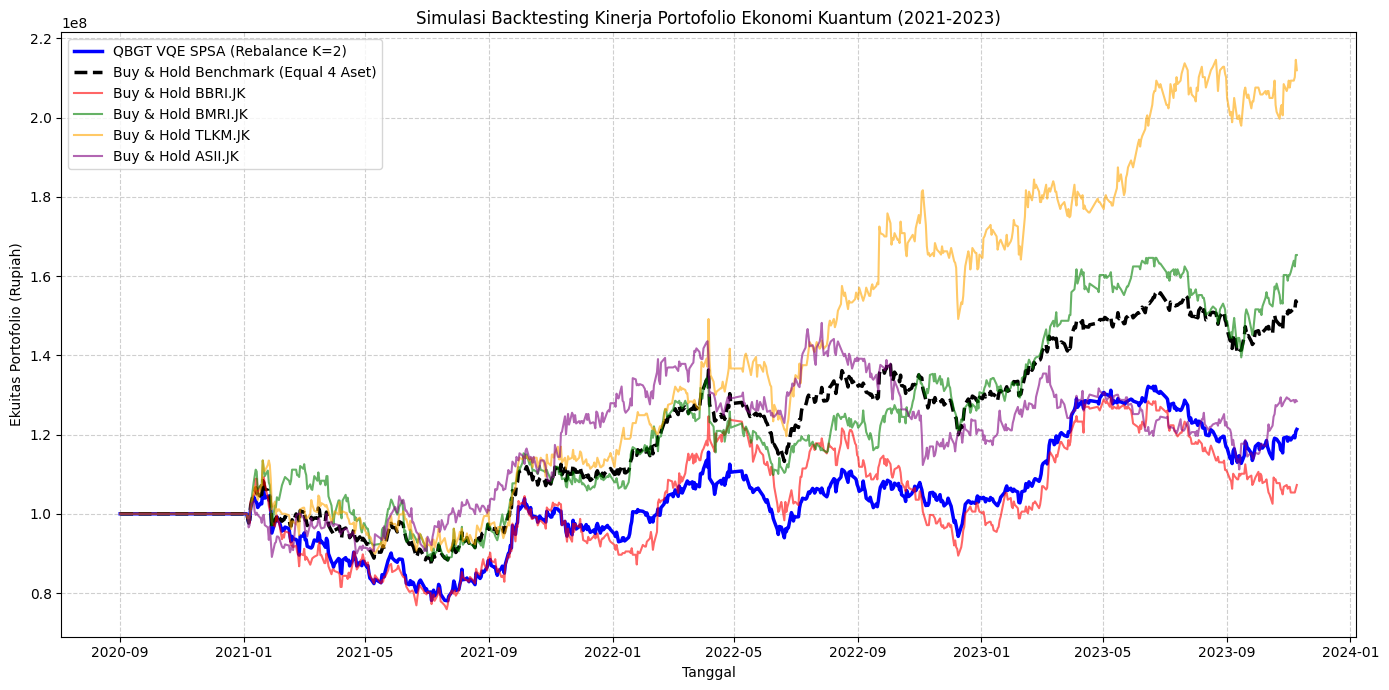

In [14]:

# === VISUALISASI PERTUMBUHAN PORTOFOLIO ===
plt.figure(figsize=(14, 7))

# Plot VQE Strategy
plt.plot(data_clean.index[:len(value_vqe)], value_vqe, label='QBGT VQE SPSA (Rebalance K=2)', linewidth=2.5, color='blue')

# Plot Buy & Hold All Equal Weights
plt.plot(data_clean.index[:len(value_bench)], value_bench, label='Buy & Hold Benchmark (Equal 4 Aset)', linewidth=2.5, color='black', linestyle='--')

# Plot Individual Buy & Hold
colors = ['red', 'green', 'orange', 'purple']
for j, t in enumerate(tickers):
    plt.plot(data_clean.index[:len(value_assets[t])], value_assets[t], label=f'Buy & Hold {t}', color=colors[j], alpha=0.6)

plt.title('Simulasi Backtesting Kinerja Portofolio Ekonomi Kuantum (2021-2023)')
plt.ylabel('Ekuitas Portofolio (Rupiah)')
plt.xlabel('Tanggal')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()
